<a href="https://colab.research.google.com/github/AlissonFelipeBS/AlissonFelipeBS/blob/main/churn_tcc_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de Cancelamento de Clientes no Setor de Telecomunicações

## MBA em Data Science e Analytics – USP/Esalq
**Aluno:** Alisson Felipe Brandão da Silva

## 1. Bibliotecas

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## 2. Carregamento dos Dados

In [172]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
dados = pd.read_csv(url)

dados.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Análise Exploratória dos Dados (EDA)

In [173]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [174]:
dados.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 3.1 Distribuição da variável alvo

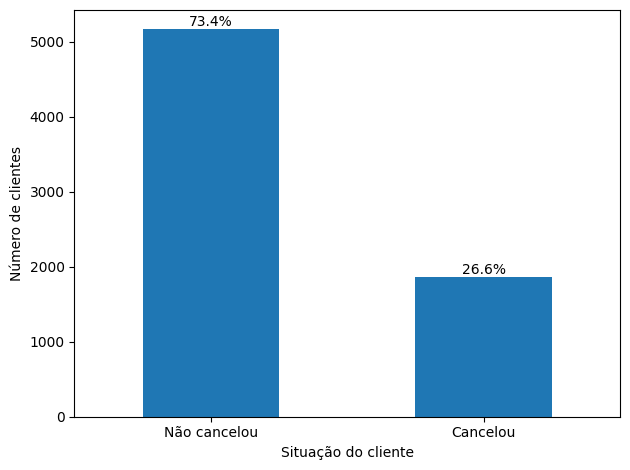

In [175]:
# Conversão antecipada para facilitar os gráficos exploratórios
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")
dados = dados.dropna()
dados["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})

contagem = dados["Churn"].value_counts()
percentual = dados["Churn"].value_counts(normalize=True) * 100

ax = contagem.plot(kind="bar")
ax.set_xlabel("Situação do cliente")
ax.set_ylabel("Número de clientes")
ax.set_xticklabels(["Não cancelou", "Cancelou"], rotation=0)

for i, v in enumerate(contagem):
    ax.text(i, v, f"{percentual.iloc[i]:.1f}%", ha="center", va="bottom")

plt.tight_layout()

plt.show()

### 3.2 Proporção de churn por tipo de contrato

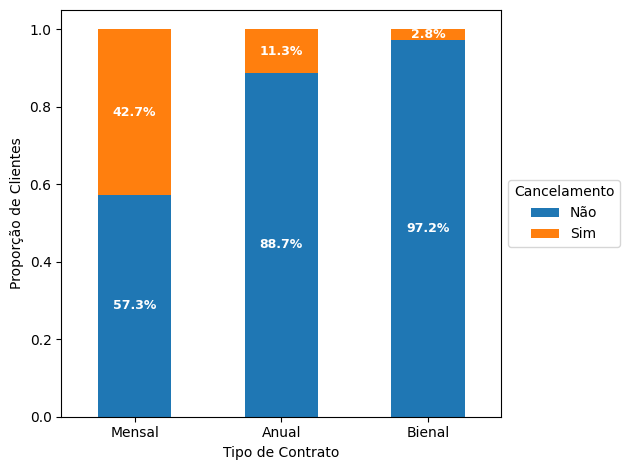

In [176]:
dados["Contract"] = dados["Contract"].replace({
    "Month-to-month": "Mensal",
    "One year": "Anual",
    "Two year": "Bienal"
})

ordem_contratos = ["Mensal", "Anual", "Bienal"]

ct = pd.crosstab(
    dados["Contract"],
    dados["Churn"],
    normalize="index"
).reindex(ordem_contratos)

ax = ct.plot(kind="bar", stacked=True)
ax.set_xticklabels(ct.index, rotation=0)
ax.set_xlabel("Tipo de Contrato")
ax.set_ylabel("Proporção de Clientes")
ax.legend(title="Cancelamento", labels=["Não", "Sim"],
          bbox_to_anchor=(1, 0.5), loc="center left")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.1f}%" for v in container.datavalues],
        label_type="center", fontsize=9, color="white", fontweight="bold"
    )

plt.tight_layout()

plt.show()

### 3.3 Tempo de permanência (tenure) por status de churn

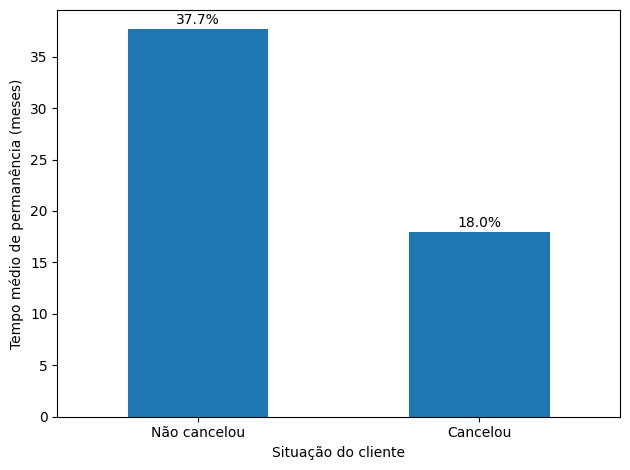

In [177]:
media_tempo = dados.groupby("Churn")["tenure"].mean()
media_tempo.index = ["Não cancelou", "Cancelou"]

ax = media_tempo.plot(kind="bar")
ax.set_xticklabels(media_tempo.index, rotation=0)
plt.xlabel("Situação do cliente")
plt.ylabel("Tempo médio de permanência (meses)")

for i, v in enumerate(media_tempo.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()

plt.show()

### 3.4 Valor médio da mensalidade (MonthlyCharges) por status de churn

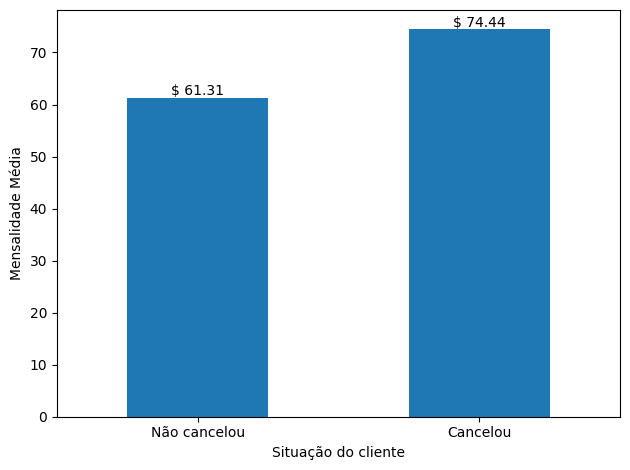

In [178]:
mensalidade = dados.groupby("Churn")["MonthlyCharges"].mean()
mensalidade.index = ["Não cancelou", "Cancelou"]

ax = mensalidade.plot(kind="bar")
ax.set_xticklabels(mensalidade.index, rotation=0)
plt.xlabel("Situação do cliente")
plt.ylabel("Mensalidade Média")

for i, v in enumerate(mensalidade.values):
    ax.text(i, v + 0.5, f"$ {v:.2f}", ha="center")

plt.tight_layout()

plt.show()

## 4. Pré-processamento

### 4.1 Separação de variáveis

In [179]:
y = dados["Churn"].reset_index(drop=True)
X = dados.drop(columns=["Churn", "customerID"])

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

### 4.2 Codificação das variáveis categóricas (One-Hot Encoding)

In [180]:
try:
    encoder = OneHotEncoder(drop="first", sparse_output=False)
    X_cat = encoder.fit_transform(X[cat_cols])
except TypeError:
    encoder = OneHotEncoder(drop="first", sparse=False)
    X_cat = encoder.fit_transform(X[cat_cols])

X_cat = pd.DataFrame(X_cat, columns=encoder.get_feature_names_out(cat_cols))

### 4.3 Padronização das variáveis numéricas

In [181]:
scaler = StandardScaler()
X_num = pd.DataFrame(scaler.fit_transform(X[num_cols]), columns=num_cols)

### 4.4 Consolidação e divisão treino/teste

In [182]:
X_prepared = pd.concat([X_num, X_cat], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(y_train.value_counts(normalize=True))

Treino: (4922, 30) | Teste: (2110, 30)
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64


## 5. Modelagem

In [183]:
# Configuração da validação cruzada e métricas (compartilhada por todos os modelos)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":        "accuracy",
    "precision_churn": make_scorer(precision_score, pos_label=1),
    "recall_churn":    make_scorer(recall_score,    pos_label=1),
    "f1_churn":        make_scorer(f1_score,        pos_label=1)
}

### 5.1 Regressão Logística (baseline)

In [184]:
modelo_baseline = LogisticRegression(max_iter=1000, random_state=42)
modelo_baseline.fit(X_train, y_train)
y_pred_lr = modelo_baseline.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.57      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



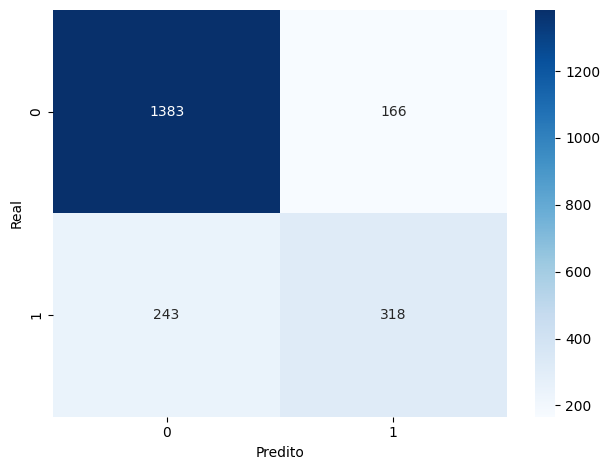

In [185]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [186]:
cv_lr = pd.DataFrame(
    cross_validate(modelo_baseline, X_prepared, y, cv=skf, scoring=scoring)
).mean()
print(cv_lr)

fit_time                0.094455
score_time              0.023004
test_accuracy           0.804607
test_precision_churn    0.657742
test_recall_churn       0.552697
test_f1_churn           0.600623
dtype: float64


### 5.2 Random Forest

In [187]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.63      0.47      0.54       561

    accuracy                           0.78      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



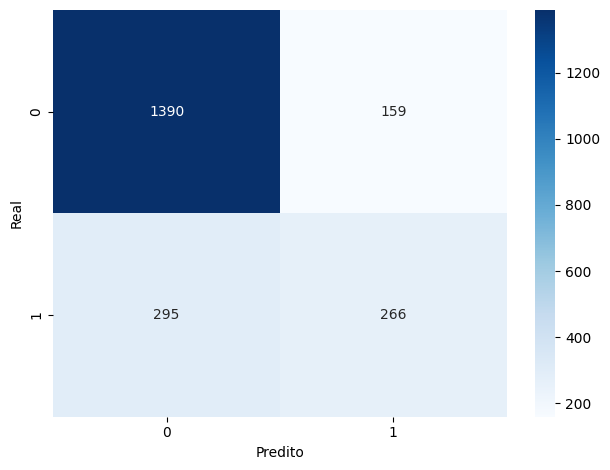

In [188]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

plt.show()

In [189]:
cv_rf = pd.DataFrame(
    cross_validate(rf_model, X_prepared, y, cv=skf, scoring=scoring)
).mean()
print(cv_rf)

fit_time                1.677418
score_time              0.079076
test_accuracy           0.792093
test_precision_churn    0.640578
test_recall_churn       0.498129
test_f1_churn           0.560259
dtype: float64


### 5.3 Random Forest Balanceado

In [190]:
rf_balanced = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42
)
rf_balanced.fit(X_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(X_test)

print(classification_report(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.61      0.46      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.69      2110
weighted avg       0.77      0.78      0.77      2110



### 5.4 Gradient Boosting

In [191]:
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.51      0.57       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.72      2110
weighted avg       0.78      0.79      0.79      2110



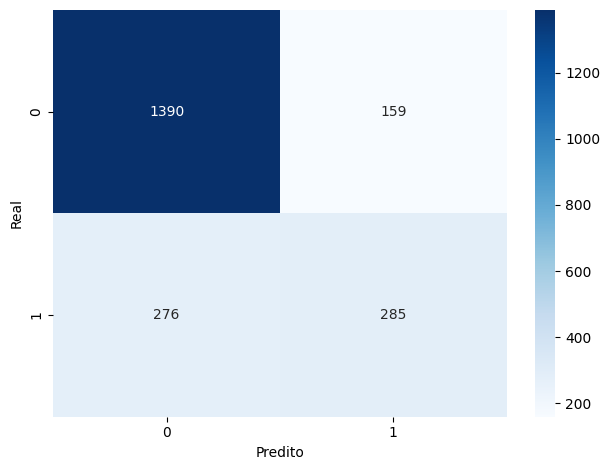

In [192]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()

plt.show()

In [193]:
cv_gb = pd.DataFrame(
    cross_validate(gb_model, X_prepared, y, cv=skf, scoring=scoring)
).mean()
print(cv_gb)

fit_time                2.412576
score_time              0.016211
test_accuracy           0.803895
test_precision_churn    0.667730
test_recall_churn       0.522737
test_f1_churn           0.586344
dtype: float64


## 6. Avaliação e Comparação dos Modelos

### 6.1 Importância das variáveis – Gradient Boosting

In [194]:
# Importancia das variáveis
feature_importances = pd.Series(
    gb_model.feature_importances_,
    index=X_prepared.columns
).sort_values(ascending=False)

feature_importances.head(15)

,0
Contract_Mensal,0.399456
tenure,0.153269
InternetService_Fiber optic,0.100479
TotalCharges,0.085342
MonthlyCharges,0.077625
PaymentMethod_Electronic check,0.048025
OnlineSecurity_Yes,0.018723
PaperlessBilling_Yes,0.015216
TechSupport_Yes,0.013865
Contract_Bienal,0.012014


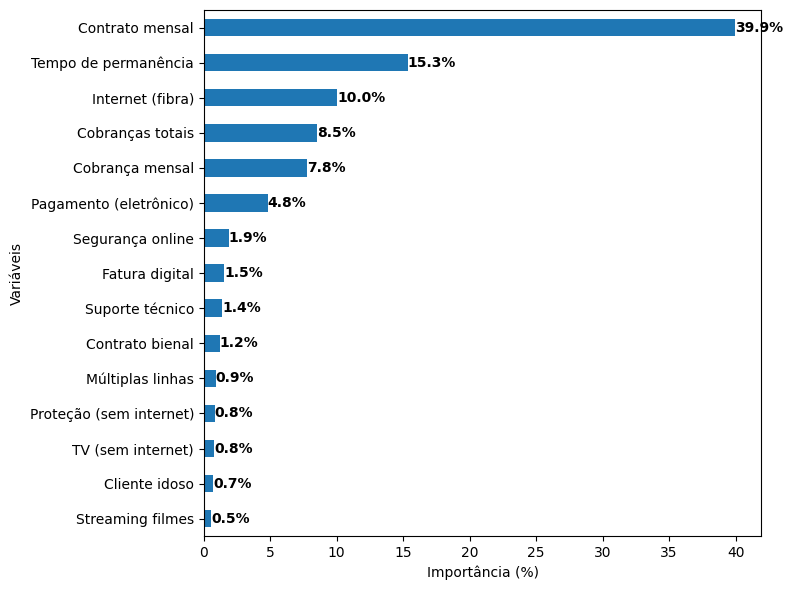

In [195]:
traducao = {
    'Contract_Mensal':                        'Contrato mensal',
    'tenure':                                 'Tempo de permanência',
    'InternetService_Fiber optic':            'Internet (fibra)',
    'TotalCharges':                           'Cobranças totais',
    'MonthlyCharges':                         'Cobrança mensal',
    'PaymentMethod_Electronic check':         'Pagamento (eletrônico)',
    'OnlineSecurity_Yes':                     'Segurança online',
    'PaperlessBilling_Yes':                   'Fatura digital',
    'TechSupport_Yes':                        'Suporte técnico',
    'Contract_Bienal':                        'Contrato bienal',
    'MultipleLines_Yes':                      'Múltiplas linhas',
    'DeviceProtection_No internet service':   'Proteção (sem internet)',
    'StreamingTV_No internet service':        'TV (sem internet)',
    'SeniorCitizen':                          'Cliente idoso',
    'StreamingMovies_Yes':                    'Streaming filmes',
}

feature_importances = pd.Series(
    gb_model.feature_importances_,
    index=X_prepared.columns
).sort_values(ascending=False)

top_features = feature_importances.head(15).sort_values() * 100  # converte para %

top_features.index = [traducao.get(v, v) for v in top_features.index]

ax = top_features.plot(kind="barh", figsize=(8, 6))

for i, v in enumerate(top_features.values):
    ax.text(v, i, f"{v:.1f}%", va="center", fontweight="bold")

plt.xlabel("Importância (%)")
plt.ylabel("Variáveis")
plt.tight_layout()

plt.show()

### 6.2 Curva ROC – Comparação entre modelos

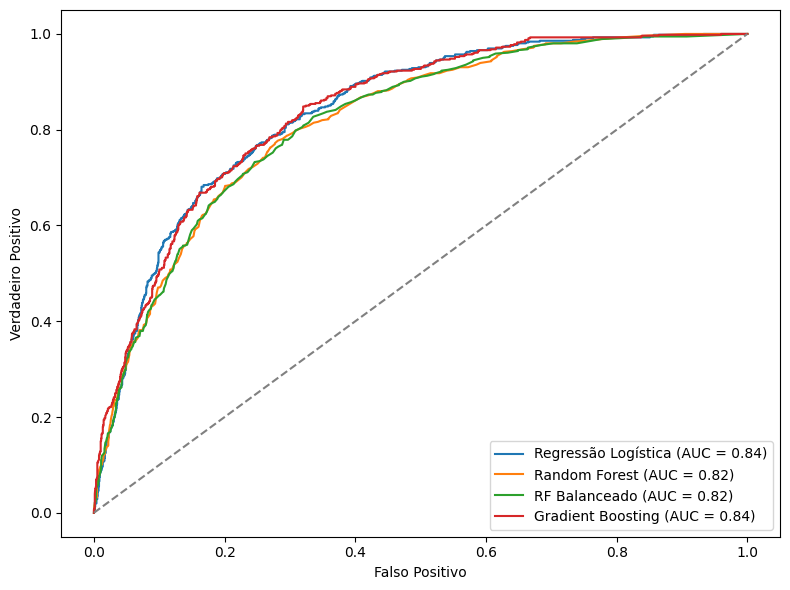

In [196]:
y_prob_lr     = modelo_baseline.predict_proba(X_test)[:, 1]
y_prob_rf     = rf_model.predict_proba(X_test)[:, 1]
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]
y_prob_gb     = gb_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))

for fpr, tpr, label, prob in [
    (*roc_curve(y_test, y_prob_lr)[:2],     "Regressão Logística", y_prob_lr),
    (*roc_curve(y_test, y_prob_rf)[:2],     "Random Forest",       y_prob_rf),
    (*roc_curve(y_test, y_prob_rf_bal)[:2], "RF Balanceado",       y_prob_rf_bal),
    (*roc_curve(y_test, y_prob_gb)[:2],     "Gradient Boosting",   y_prob_gb),
]:
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_test, prob):.2f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Falso Positivo")
plt.ylabel("Verdadeiro Positivo")
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

### 6.3 Tabela comparativa de métricas

In [197]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Random Forest",
        "Random Forest Balanceado",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_balanced),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_balanced),
        precision_score(y_test, y_pred_gb)
    ],
    "Recall_Churn": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_balanced),
        recall_score(y_test, y_pred_gb)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_balanced),
        f1_score(y_test, y_pred_gb)
    ]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall_Churn,F1-Score
0,Regressão Logística,0.806161,0.657025,0.566845,0.608612
1,Random Forest,0.784834,0.625882,0.474153,0.539554
2,Random Forest Balanceado,0.778673,0.610849,0.461676,0.525888
3,Gradient Boosting,0.793839,0.641892,0.508021,0.567164


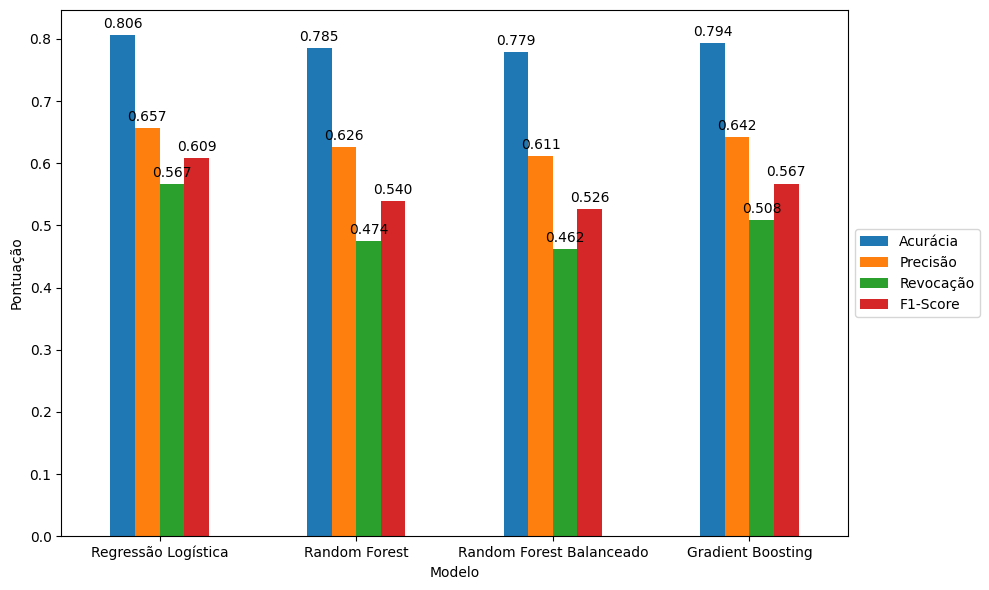

In [200]:
ax = resultados_modelos.set_index("Modelo")[["Accuracy", "Precision", "Recall_Churn", "F1-Score"]].rename(columns={
    "Accuracy":     "Acurácia",
    "Precision":    "Precisão",
    "Recall_Churn": "Revocação",
    "F1-Score":     "F1-Score"
}).plot(kind="bar", figsize=(10, 6))

plt.ylabel("Pontuação")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()